# Retail Customer Analytics: Sales Prediction, Customer Segmentation and Business Insights
### A future-value and returns-aware approach

**Module:** Fundamentals of Data Analytics (MSc Data Analytics, BSBI)
**Dataset:** Online Retail (`Online Retail.xlsx`, read from the local folder)

**Main idea:** instead of describing what customers *already* spent, we use behaviour up to **31 August 2011** to predict what each customer will be worth from **1 September 2011** onwards (the holiday season). Returns and cancellations are kept and used, not just deleted.

**How to run:** the Excel file path is set in cell 1.1, then choose **Run All**. The last cell saves `results_summary.json` for the report.

| Section | Assignment task |
|---|---|
| 1 | Task 1: business context, data understanding, statistics |
| 2 | Task 2: cleaning, features, time split, scaling, distance, maths |
| 3 | Exploratory data analysis (EDA) |
| 4 | Task 3: regression (predict next-season spend) |
| 5 | Task 4A: classification (next-season status) |
| 6 | Task 4B: clustering (returns-aware segments) |
| 7 | Task 5 and 6: insights, limitations, reproducibility |

In [1]:
# ---------- 0. SETUP: import the libraries we need ----------
import os, json, warnings

import numpy as np                  # numbers and arrays
import pandas as pd                 # tables (DataFrames)
import matplotlib.pyplot as plt     # charts
import seaborn as sns               # nicer charts
from scipy import stats             # skewness and Q-Q plot

# scikit-learn: machine learning tools
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report,
                             silhouette_score)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")          # hide harmless warnings so the output stays clean
sns.set_theme(style="whitegrid")           # chart style
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")   # show numbers with 2 decimals
pd.set_option("display.max_columns", 30)

SEED = 42                                  # fixed random seed -> same results every run (reproducible)
np.random.seed(SEED)

RESULTS = {}                               # a dictionary where we collect key numbers for the report

## 1. Task 1: Business context, data understanding and statistical foundations

**Business scenario:** customer value for an online gift retailer, looking forward instead of backward.

**Business problem:** before the busy autumn season, marketing must decide which customers to invest in. Past spend alone is a weak guide: some big buyers return goods, and others never come back. The company needs to know who will be valuable *next*.

**Stakeholders:** marketing team (campaign budget), customer relationship team (retention), senior management (planning).

**Analytical questions**
1. Can past behaviour, including returns, predict how much a customer will spend next season? (regression)
2. Can we predict whether a customer will be inactive, low-value or high-value next season? (classification)
3. Which customer segments exist, and do they really behave differently next season? (clustering)
4. How big is the returns problem, and how do sales change over time and across countries? (EDA)

In [2]:
# ---------- 1.1 LOAD THE DATA ----------

file_path = "Online Retail.xlsx"

# Read the Excel file into a table called raw.
# dtype=str keeps InvoiceNo and StockCode as text (so codes like 'C536379' stay correct).
raw = pd.read_excel(file_path, dtype={"InvoiceNo": str, "StockCode": str})

print("Shape (rows, columns):", raw.shape)
print("Columns:", list(raw.columns))
raw.head()   # show the first 5 rows

Shape (rows, columns): (541909, 8)
Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom


In [3]:
# ---------- 1.2 DATA DICTIONARY AND VARIABLE TYPES ----------
data_dictionary = pd.DataFrame({
    "Column": ["InvoiceNo", "StockCode", "Description", "Quantity", "InvoiceDate", "UnitPrice", "CustomerID", "Country"],
    "Meaning": ["Invoice number (starts with C if cancelled)", "Product code", "Product name",
                "Units bought on the line", "Date and time of invoice", "Price per unit (GBP)",
                "Customer identifier", "Customer country"],
    "Variable type": ["Categorical (identifier)", "Categorical (identifier)", "Categorical (text)",
                      "Numerical (discrete)", "Temporal", "Numerical (continuous)",
                      "Categorical (identifier)", "Categorical (nominal)"],
})
data_dictionary

,Column,Meaning,Variable type
0,InvoiceNo,Invoice number (starts with C if cancelled),Categorical (identifier)
1,StockCode,Product code,Categorical (identifier)
2,Description,Product name,Categorical (text)
3,Quantity,Units bought on the line,Numerical (discrete)
4,InvoiceDate,Date and time of invoice,Temporal
5,UnitPrice,Price per unit (GBP),Numerical (continuous)
6,CustomerID,Customer identifier,Categorical (identifier)
7,Country,Customer country,Categorical (nominal)


**Why variable types matter:** numerical columns can be averaged and used in regression; categorical columns must be encoded first; identifiers are labels (never averaged); dates let us build Recency and split the data by time. The raw data has no ordinal variable, but the next-season status we create in Section 5 (Inactive < Low-value < High-value) is ordinal.

In [4]:
# ---------- 1.3 DATA TYPES AND MISSING VALUES (raw data) ----------
data_summary = pd.DataFrame({
    "data type": raw.dtypes.astype(str),
    "missing values": raw.isna().sum(),
    "missing %": raw.isna().mean() * 100,
    "unique values": raw.nunique(),
})
data_summary

,data type,missing values,missing %,unique values
InvoiceNo,object,0,0.00,25900
StockCode,object,0,0.00,4070
Description,object,1454,0.27,4223
Quantity,int64,0,0.00,722
InvoiceDate,datetime64[ns],0,0.00,23260
UnitPrice,float64,0,0.00,1630
CustomerID,float64,135080,24.93,4372
Country,object,0,0.00,38


In [5]:
# ---------- 1.4 DESCRIPTIVE STATISTICS (raw data, before cleaning) ----------
# TotalPrice = how much money one invoice line brought in
raw["TotalPrice"] = raw["Quantity"] * raw["UnitPrice"]

def describe_full(series):
    # Returns the statistics asked for in the brief for one column.
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    return pd.Series({
        "mean": series.mean(),
        "median": series.median(),
        "mode": series.mode().iloc[0],       # most common value
        "min": series.min(),
        "max": series.max(),
        "range": series.max() - series.min(),
        "variance": series.var(),
        "std": series.std(),                 # standard deviation
        "Q1": q1,
        "Q3": q3,
        "IQR": q3 - q1,                      # interquartile range
    })

raw_descriptives = raw[["Quantity", "UnitPrice", "TotalPrice"]].apply(describe_full).T
raw_descriptives

,mean,median,mode,min,max,range,variance,std,Q1,Q3,IQR
Quantity,9.55,3.00,1.00,"-80,995.00","80,995.00","161,990.00","47,559.39",218.08,1.00,10.00,9.00
UnitPrice,4.61,2.08,1.25,"-11,062.06","38,970.00","50,032.06","9,362.47",96.76,1.25,4.13,2.88
TotalPrice,17.99,9.75,15.00,"-168,469.60","168,469.60","336,939.20","143,497.64",378.81,3.40,17.40,14.00


**How to read this table:** when the mean is far from the median the data is skewed. A negative minimum means returns or errors. Both must be handled in Section 2.

**Linear algebra view of the modelling task.** For *n* customers and *p* predictors:

$$X \in \mathbb{R}^{n \times p}, \qquad y \in \mathbb{R}^{n}, \qquad \hat{y} = X\beta$$

Each row of $X$ is one customer, each column is one feature measured **before** 1 September 2011 (Recency, Frequency, ...). $y$ is what the customer spends **after** 1 September 2011. Regression finds $\beta$ so that $X\beta$ is close to $y$.

## 2. Task 2: Data cleaning, preprocessing and feature engineering
Every cleaning rule is counted, so the report can show a before-and-after table.
**Special rule in this project:** cancelled invoices are **kept as negative "return" lines** instead of being deleted. This lets us measure each customer's return behaviour and their true net spend.

In [6]:
# ---------- 2.1 DATA QUALITY CHECKS (counts of each problem in the raw data) ----------
quality_checks = {
    "Rows in raw data": len(raw),
    "Missing CustomerID": int(raw["CustomerID"].isna().sum()),
    "Missing Description": int(raw["Description"].isna().sum()),
    "Exact duplicate rows": int(raw.duplicated().sum()),
    "Cancelled invoices (InvoiceNo starts with C)": int(raw["InvoiceNo"].str.startswith("C").sum()),
    "Negative or zero Quantity": int((raw["Quantity"] <= 0).sum()),
    "Zero or negative UnitPrice": int((raw["UnitPrice"] <= 0).sum()),
}
pd.Series(quality_checks, name="count").to_frame()

,count
Rows in raw data,541909
Missing CustomerID,135080
Missing Description,1454
Exact duplicate rows,5268
Cancelled invoices (InvoiceNo starts with C),9288
Negative or zero Quantity,10624
Zero or negative UnitPrice,2517


In [7]:
# ---------- 2.2 CLEANING (one step at a time, each step is logged) ----------
cleaning_log = []          # will hold: step name, rows removed, rows left

def log_step(step_name, rows_before, rows_after):
    # Adds one line to the cleaning log.
    cleaning_log.append({"Step": step_name, "Rows removed": rows_before - rows_after, "Rows left": rows_after})

df = raw.copy()            # work on a copy so the raw data stays untouched

# Step 1: remove exact duplicate rows (double entries would inflate revenue)
before = len(df)
df = df.drop_duplicates()
log_step("1. Drop exact duplicate rows", before, len(df))

# Step 2: remove non-product codes (postage, bank charges, manual entries): not real product sales
non_product_codes = ["POST", "D", "M", "BANK CHARGES", "DOT", "CRUK", "C2", "AMAZONFEE", "S", "B", "PADS", "m"]
before = len(df)
df = df[~df["StockCode"].isin(non_product_codes)]
log_step("2. Remove non-product stock codes (postage, fees, manual)", before, len(df))

# Step 3: remove rows where UnitPrice is zero or negative (free items, bad-debt adjustments)
before = len(df)
df = df[df["UnitPrice"] > 0]
log_step("3. Remove UnitPrice <= 0", before, len(df))

# Step 4: remove stock adjustments = rows with Quantity <= 0 that are NOT cancelled invoices.
# Cancelled invoices (start with C) are KEPT: they are the customer returns we want to study.
is_cancelled = df["InvoiceNo"].str.startswith("C")
before = len(df)
df = df[is_cancelled | (df["Quantity"] > 0)]
log_step("4. Remove Quantity <= 0 that are not cancelled invoices", before, len(df))

# Small fixes: fill missing product names, make sure dates are real dates
df["Description"] = df["Description"].fillna("UNKNOWN").str.strip()
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Mark returns and give every line a signed value:
# sales are positive, returns are negative (so a sum gives NET revenue).
df["IsReturn"] = df["InvoiceNo"].str.startswith("C")
df["TotalPrice"] = df["Quantity"].abs() * df["UnitPrice"]
df.loc[df["IsReturn"], "TotalPrice"] = -df.loc[df["IsReturn"], "TotalPrice"]
print("Return lines kept:", int(df["IsReturn"].sum()))

# Keep this version (it still contains rows with no CustomerID).
# We use it for sales charts (revenue, products, countries), because those do not need a customer ID.
clean_all = df.copy()

# Step 5: remove rows with no CustomerID. We can not guess an ID, so these rows
# are dropped for customer-level analysis only.
before = len(df)
df = df.dropna(subset=["CustomerID"])
log_step("5. Drop rows with missing CustomerID (customer-level work only)", before, len(df))

df["CustomerID"] = df["CustomerID"].astype(int).astype(str)   # ID is a label, so store it as text

pd.DataFrame(cleaning_log)

Return lines kept: 8668


,Step,Rows removed,Rows left
0,1. Drop exact duplicate rows,5268,536641
1,"2. Remove non-product stock codes (postage, fe...",2910,533731
2,3. Remove UnitPrice <= 0,2495,531236
3,4. Remove Quantity <= 0 that are not cancelled...,0,531236
4,5. Drop rows with missing CustomerID (customer...,131580,399656


In [8]:
# ---------- 2.3 TRANSACTION-LEVEL FEATURES ----------
# We add the same new columns to both tables.
for table in (clean_all, df):
    table["InvoiceMonth"] = table["InvoiceDate"].dt.to_period("M").astype(str)     # e.g. 2011-03
    table["InvoiceDay"] = table["InvoiceDate"].dt.day_name()                       # e.g. Monday
    table["InvoiceHour"] = table["InvoiceDate"].dt.hour                            # 0 to 23

# How much net revenue has no CustomerID? (tells us how much we lose in customer analysis)
missing_id_revenue = clean_all.loc[clean_all["CustomerID"].isna(), "TotalPrice"].sum()
missing_id_share = missing_id_revenue / clean_all["TotalPrice"].sum() * 100
print(f"Net revenue with missing CustomerID: {missing_id_share:.1f}%")

# How big are returns compared with sales?
sales_value = clean_all.loc[~clean_all["IsReturn"], "TotalPrice"].sum()
return_value = -clean_all.loc[clean_all["IsReturn"], "TotalPrice"].sum()
print(f"Sales = {sales_value:,.0f} | Returns = {return_value:,.0f} | Returns are {return_value / sales_value * 100:.1f}% of sales")
print("Rows: raw =", len(raw), "| cleaned (all) =", len(clean_all), "| cleaned (with CustomerID) =", len(df))

# Save key numbers for the report
RESULTS["rows_raw"] = len(raw)
RESULTS["rows_clean_all"] = len(clean_all)
RESULTS["rows_clean_customer"] = len(df)
RESULTS["return_lines_kept"] = int(clean_all["IsReturn"].sum())
RESULTS["revenue_share_missing_customerid_pct"] = round(missing_id_share, 1)
RESULTS["sales_value"] = round(sales_value)
RESULTS["return_value"] = round(return_value)
RESULTS["returns_pct_of_sales"] = round(return_value / sales_value * 100, 1)

df[["InvoiceNo", "Quantity", "UnitPrice", "TotalPrice", "IsReturn", "InvoiceMonth"]].head()

Net revenue with missing CustomerID: 15.4%
Sales = 10,247,905 | Returns = 475,901 | Returns are 4.6% of sales
Rows: raw = 541909 | cleaned (all) = 531236 | cleaned (with CustomerID) = 399656


,InvoiceNo,Quantity,UnitPrice,TotalPrice,IsReturn,InvoiceMonth
0,536365,6,2.55,15.30,False,2010-12
1,536365,6,3.39,20.34,False,2010-12
2,536365,8,2.75,22.00,False,2010-12
3,536365,6,3.39,20.34,False,2010-12
4,536365,6,3.39,20.34,False,2010-12


In [9]:
# ---------- 2.4 OUTLIERS (IQR rule on sales lines) ----------
# A value above  Q3 + 1.5 x IQR  is treated as an outlier. We FLAG them but do not delete them.
sales_lines = df[~df["IsReturn"]]
q1 = sales_lines["TotalPrice"].quantile(0.25)
q3 = sales_lines["TotalPrice"].quantile(0.75)
upper_fence = q3 + 1.5 * (q3 - q1)
n_outliers = int((sales_lines["TotalPrice"] > upper_fence).sum())

print(f"Upper fence = {upper_fence:.2f} | lines above it = {n_outliers} ({n_outliers / len(sales_lines) * 100:.1f}%)")
print("\nLargest single sales lines:")
print(sales_lines.nlargest(4, "TotalPrice")[["InvoiceNo", "InvoiceDate", "CustomerID", "Description", "Quantity", "TotalPrice"]])

RESULTS["outlier_fence_totalprice"] = round(upper_fence, 2)
RESULTS["outlier_share_pct"] = round(n_outliers / len(sales_lines) * 100, 1)

Upper fence = 42.07 | lines above it = 30484 (7.8%)

Largest single sales lines:
       InvoiceNo         InvoiceDate CustomerID  \
540421    581483 2011-12-09 09:15:00      16446   
61619     541431 2011-01-18 10:01:00      12346   
222680    556444 2011-06-10 15:28:00      15098   
348325    567423 2011-09-20 11:05:00      17450   

                                Description  Quantity  TotalPrice  
540421          PAPER CRAFT , LITTLE BIRDIE     80995  168,469.60  
61619        MEDIUM CERAMIC TOP STORAGE JAR     74215   77,183.60  
222680       PICNIC BASKET WICKER 60 PIECES        60   38,970.00  
348325  SET OF TEA COFFEE SUGAR TINS PANTRY      1412    7,144.72  


In [10]:
# ---------- 2.5 THE TWO HUGE CANCELLED ORDERS (why keeping returns matters) ----------
# Two of the biggest sales were cancelled straight away. Plain 'delete cancelled rows' would keep the sale.
for cust_id, product in [("12346", "MEDIUM CERAMIC TOP STORAGE JAR"), ("16446", "PAPER CRAFT , LITTLE BIRDIE")]:
    lines = df[(df["CustomerID"] == cust_id) & (df["Description"] == product)]
    print(f"Customer {cust_id}, {product}: sales = {lines.loc[~lines['IsReturn'], 'TotalPrice'].sum():,.2f} | "
          f"returns = {lines.loc[lines['IsReturn'], 'TotalPrice'].sum():,.2f} | NET = {lines['TotalPrice'].sum():,.2f}")

NAIVE_KEEP = sales_lines.nlargest(2, "TotalPrice")["TotalPrice"].sum()
RESULTS["two_big_orders_sales_value"] = round(NAIVE_KEEP)

Customer 12346, MEDIUM CERAMIC TOP STORAGE JAR: sales = 77,183.60 | returns = -77,183.60 | NET = 0.00
Customer 16446, PAPER CRAFT , LITTLE BIRDIE: sales = 168,469.60 | returns = -168,469.60 | NET = 0.00


**Outlier decision:** large orders are usually real wholesale buyers, so we **keep** them and reduce their pull with a **log transform** later. But an order that was cancelled straight away is not a real sale. Because we keep returns as negative lines, these two orders now net out to zero automatically.

**Missing CustomerID:** an ID cannot be guessed. Filling it in would create fake customers, so those rows are removed for customer-level work only. They stay in the sales charts.

In [11]:
# ---------- 2.6 SPLIT THE TIME LINE: observation window and prediction window ----------
# We build features from the PAST (observation window) and measure the target in the FUTURE (prediction window).
CUTOFF = pd.Timestamp("2011-09-01")

observed = df[df["InvoiceDate"] < CUTOFF]       # 1 Dec 2010 - 31 Aug 2011  -> used for features (X)
future = df[df["InvoiceDate"] >= CUTOFF]        # 1 Sep 2011 - 9 Dec 2011   -> used for the target (y)

print("Observation window:", observed["InvoiceDate"].min().date(), "to", observed["InvoiceDate"].max().date(), "| rows:", len(observed))
print("Prediction window :", future["InvoiceDate"].min().date(), "to", future["InvoiceDate"].max().date(), "| rows:", len(future))
RESULTS["rows_observation"] = len(observed)
RESULTS["rows_prediction"] = len(future)

Observation window: 2010-12-01 to 2011-08-31 | rows: 228436
Prediction window : 2011-09-01 to 2011-12-09 | rows: 171220


In [12]:
# ---------- 2.7 CUSTOMER-LEVEL FEATURES (one row per customer, from the observation window only) ----------
obs_sales = observed[~observed["IsReturn"]]        # only real sales
obs_returns = observed[observed["IsReturn"]]       # only returns

# Group all sales lines by customer and summarise them
customers = obs_sales.groupby("CustomerID").agg(
    LastPurchase=("InvoiceDate", "max"),
    FirstPurchase=("InvoiceDate", "min"),
    Frequency=("InvoiceNo", "nunique"),          # number of different invoices
    GrossSpend=("TotalPrice", "sum"),            # total money spent on sales (before returns)
    TotalQty=("Quantity", "sum"),                # total units bought
    UniqueProducts=("StockCode", "nunique"),     # number of different products bought
    AvgUnitPrice=("UnitPrice", "mean"),          # average price of the items bought
    Country=("Country", lambda x: x.mode().iloc[0]),   # the country used most often
)

# Money returned by each customer (positive number), 0 if the customer never returned anything
return_value_by_customer = -obs_returns.groupby("CustomerID")["TotalPrice"].sum()
customers["ReturnValue"] = return_value_by_customer.reindex(customers.index).fillna(0)

customers["ReturnRate"] = (customers["ReturnValue"] / customers["GrossSpend"]).clip(0, 1)   # share of spend returned (0 to 1)
customers["NetSpend"] = customers["GrossSpend"] - customers["ReturnValue"]                  # spend after returns
customers["Recency"] = (CUTOFF - customers["LastPurchase"]).dt.days                         # days since last purchase
customers["AvgBasket"] = customers["GrossSpend"] / customers["Frequency"]                   # average money per order
customers["TenureDays"] = (customers["LastPurchase"] - customers["FirstPurchase"]).dt.days  # days between first and last purchase
customers["IsUK"] = (customers["Country"] == "United Kingdom").astype(int)                  # encoding: 1 = UK, 0 = other
customers = customers.drop(columns=["LastPurchase", "FirstPurchase"])

# TARGET: what each customer spends AFTER the cutoff (net of returns). Customers who did not buy get 0.
future_spend = future.groupby("CustomerID")["TotalPrice"].sum()
customers["FutureSpend"] = future_spend.reindex(customers.index).fillna(0).clip(lower=0)
customers["ActiveNext"] = (customers["FutureSpend"] > 0).astype(int)      # 1 = bought again next season

print("Number of customers (bought before the cutoff):", len(customers))
print(f"Customers who bought again after the cutoff: {customers['ActiveNext'].mean() * 100:.1f}%")
print(f"Customers with at least one return before the cutoff: {(customers['ReturnValue'] > 0).mean() * 100:.1f}%")

RESULTS["n_customers"] = len(customers)
RESULTS["active_next_pct"] = round(customers["ActiveNext"].mean() * 100, 1)
RESULTS["customers_with_returns_pct"] = round((customers["ReturnValue"] > 0).mean() * 100, 1)
customers.head()

Number of customers (bought before the cutoff): 3314
Customers who bought again after the cutoff: 58.5%
Customers with at least one return before the cutoff: 33.6%


,Frequency,GrossSpend,TotalQty,UniqueProducts,AvgUnitPrice,Country,ReturnValue,ReturnRate,NetSpend,Recency,AvgBasket,TenureDays,IsUK,FutureSpend,ActiveNext
CustomerID,,,,,,,,,,,,,,,
12346,1,"77,183.60",74215,1,1.04,United Kingdom,"77,183.60",1.00,0.00,225,"77,183.60",0,1,0.00,0
12347,5,"2,790.86",1590,82,2.80,Iceland,0.00,0.00,"2,790.86",29,558.17,237,0,"1,519.14",1
12348,3,"1,167.24",2116,21,0.65,Finland,0.00,0.00,"1,167.24",148,389.08,109,0,270.00,1
12350,1,294.40,196,16,1.58,Norway,0.00,0.00,294.40,210,294.40,0,0,0.00,0
12352,4,641.51,249,24,3.72,Norway,120.33,0.19,521.18,162,160.38,34,0,744.23,1


In [13]:
# ---------- 2.8 ENCODING A CATEGORICAL FEATURE ----------
# Machine learning models need numbers, not text. Country has many values, so we group it
# into "UK" and "Other" and one-hot encode it. drop_first=True keeps one column (no duplicate information).
country_group = customers["Country"].where(customers["Country"] == "United Kingdom", "Other")
encoded = pd.get_dummies(country_group, prefix="Country", drop_first=True)
print(encoded.head(3))
print("\nOur IsUK column holds the same information: 1 = UK, 0 = Other.")

            Country_United Kingdom
CustomerID                        
12346                         True
12347                        False
12348                        False

Our IsUK column holds the same information: 1 = UK, 0 = Other.


In [14]:
# ---------- 2.9 SCALING: standardisation and min-max on two features ----------
two_features = customers[["Recency", "Frequency"]]

standardised = StandardScaler().fit_transform(two_features)     # z = (x - mean) / std
min_max = MinMaxScaler().fit_transform(two_features)            # (x - min) / (max - min)

comparison = pd.concat([
    two_features,
    pd.DataFrame(standardised, columns=["Recency_z", "Frequency_z"], index=customers.index),
    pd.DataFrame(min_max, columns=["Recency_minmax", "Frequency_minmax"], index=customers.index),
], axis=1)
print(comparison.head())
print("\nAfter standardising: mean =", standardised.mean(axis=0).round(3), "| std =", standardised.std(axis=0).round(3))

            Recency  Frequency  Recency_z  Frequency_z  Recency_minmax  \
CustomerID                                                               
12346           225          1       1.73        -0.44            0.82   
12347            29          5      -0.82         0.28            0.11   
12348           148          3       0.73        -0.08            0.54   
12350           210          1       1.53        -0.44            0.77   
12352           162          4       0.91         0.10            0.59   

            Frequency_minmax  
CustomerID                    
12346                   0.00  
12347                   0.03  
12348                   0.02  
12350                   0.00  
12352                   0.02  

After standardising: mean = [0. 0.] | std = [1. 1.]


**Standardisation:** $z = \dfrac{x - \mu}{\sigma}$. Every feature gets mean 0 and standard deviation 1. This matters because Recency is in days (up to about 270) while Frequency is a small count. Without scaling, big numbers would dominate distance calculations.

**Min-max:** $x' = \dfrac{x - x_{min}}{x_{max} - x_{min}}$ squeezes values into 0 to 1.

**Revenue formula:** sales lines are positive and return lines are negative, so $\text{Net spend}_c = \sum_{i \in c}\text{TotalPrice}_i$ and $\text{ReturnRate}_c = \dfrac{\text{returned value}}{\text{gross spend}}$.

In [15]:
# ---------- 2.10 SIMILARITY AND DISTANCE (on the clustering features) ----------
# Clustering features: Recency, Frequency, Monetary (gross spend) and ReturnRate.
# log1p(x) = log(1 + x) reduces skew for the first three. ReturnRate is already between 0 and 1.
cluster_data = pd.DataFrame({
    "Recency": np.log1p(customers["Recency"]),
    "Frequency": np.log1p(customers["Frequency"]),
    "Monetary": np.log1p(customers["GrossSpend"]),
    "ReturnRate": customers["ReturnRate"],
})
cluster_scaled = StandardScaler().fit_transform(cluster_data)      # every column: mean 0, std 1

# Compare the first two customers
a = cluster_scaled[0]
b = cluster_scaled[1]

euclidean = np.sqrt(np.sum((a - b) ** 2))                       # straight-line distance
manhattan = np.sum(np.abs(a - b))                                # "city block" distance
cosine = cosine_similarity(a.reshape(1, -1), b.reshape(1, -1))[0, 0]   # similarity of direction (1 = same)

print(f"Customers {customers.index[0]} and {customers.index[1]} (scaled features):")
print(f"Euclidean = {euclidean:.3f} | Manhattan = {manhattan:.3f} | Cosine similarity = {cosine:.3f}")

# Same two customers on RAW values: Monetary (in pounds) dominates the distance
raw_features = customers[["Recency", "Frequency", "GrossSpend", "ReturnRate"]]
raw_a = raw_features.iloc[0].values
raw_b = raw_features.iloc[1].values
print(f"Euclidean on RAW values = {np.sqrt(np.sum((raw_a - raw_b) ** 2)):.1f}  (dominated by spend in pounds)")

RESULTS["distance_example"] = {"euclidean_scaled": round(float(euclidean), 3),
                               "manhattan_scaled": round(float(manhattan), 3),
                               "cosine_scaled": round(float(cosine), 3),
                               "euclidean_raw": round(float(np.sqrt(np.sum((raw_a - raw_b) ** 2))), 1)}

Customers 12346 and 12347 (scaled features):
Euclidean = 12.727 | Manhattan = 18.404 | Cosine similarity = 0.026
Euclidean on RAW values = 74393.0  (dominated by spend in pounds)


**Euclidean distance:** $d(a,b) = \sqrt{\sum_i (a_i - b_i)^2}$. K-means uses it: small distance = similar customers.
**Cosine similarity** compares the direction of two vectors, not their size.

In [16]:
# ---------- 2.11 INTEGRATION: total net revenue as area under the daily revenue curve ----------
daily_revenue = clean_all.set_index("InvoiceDate")["TotalPrice"].resample("D").sum()   # net revenue per day
day_number = np.arange(len(daily_revenue))

# Trapezoid rule = numerical integration. (np.trapezoid in new NumPy, np.trapz in old NumPy)
trapezoid = getattr(np, "trapezoid", None) or np.trapz
area = trapezoid(daily_revenue.values, day_number)

print(f"Area under the daily revenue curve (trapezoid rule) = {area:,.0f}")
print(f"Simple sum of daily revenue                         = {daily_revenue.sum():,.0f}  (should be close)")
RESULTS["integration_check"] = {"trapezoid_area": round(float(area)), "sum_daily": round(float(daily_revenue.sum()))}

Area under the daily revenue curve (trapezoid rule) = 9,728,667
Simple sum of daily revenue                         = 9,772,004  (should be close)


**Calculus link (LO3):** total revenue is the integral of daily revenue $R(t)$:

$$\text{Total revenue} = \int_0^T R(t)\,dt \approx \sum_t R(t)\,\Delta t$$

## 3. Exploratory data analysis (visualisations)
Each chart has a title and axis labels.

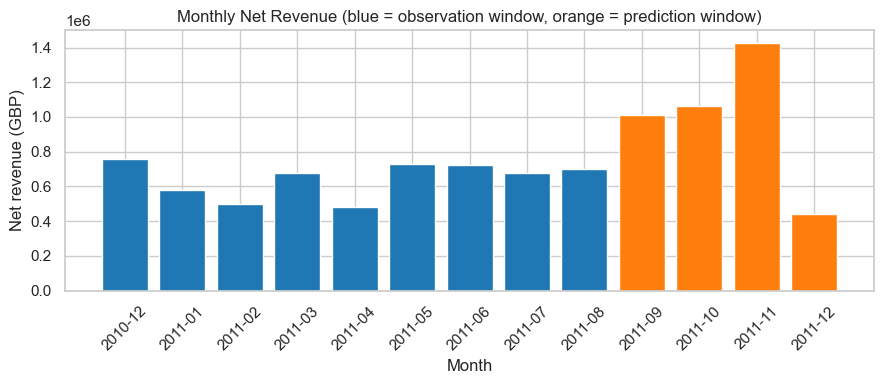

In [17]:
# ---------- FIGURE: monthly net revenue, coloured by window ----------
monthly_revenue = clean_all.groupby("InvoiceMonth")["TotalPrice"].sum()
bar_colours = ["#1f77b4" if month < "2011-09" else "#ff7f0e" for month in monthly_revenue.index]

plt.figure(figsize=(9, 4))
plt.bar(monthly_revenue.index, monthly_revenue.values, color=bar_colours)
plt.title("Monthly Net Revenue (blue = observation window, orange = prediction window)")
plt.xlabel("Month")
plt.ylabel("Net revenue (GBP)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

RESULTS["best_month"] = monthly_revenue.idxmax()
RESULTS["best_month_revenue"] = round(monthly_revenue.max())
RESULTS["monthly_revenue"] = {month: round(value) for month, value in monthly_revenue.items()}

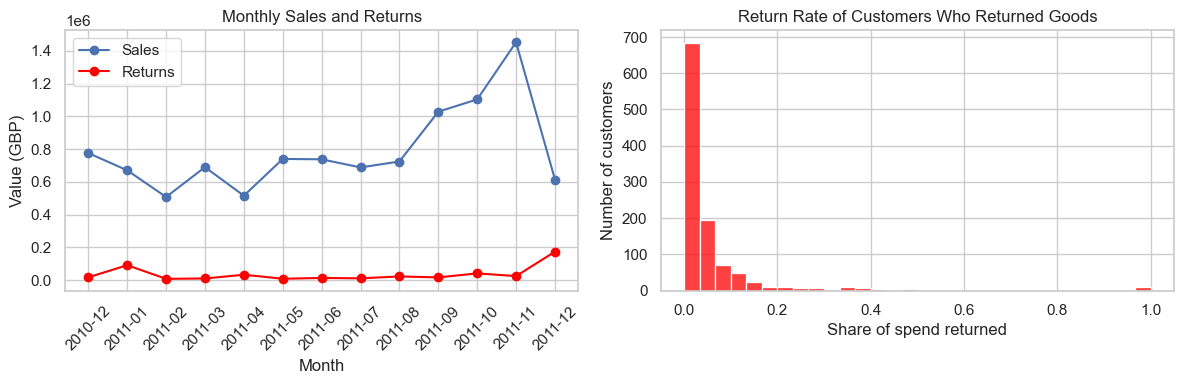

In [18]:
# ---------- FIGURE: returns (how big is the problem?) ----------
monthly_sales = clean_all[~clean_all["IsReturn"]].groupby("InvoiceMonth")["TotalPrice"].sum()
monthly_returns = -clean_all[clean_all["IsReturn"]].groupby("InvoiceMonth")["TotalPrice"].sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(monthly_sales.index, monthly_sales.values, marker="o", label="Sales")
axes[0].plot(monthly_returns.index, monthly_returns.values, marker="o", color="red", label="Returns")
axes[0].set_title("Monthly Sales and Returns")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Value (GBP)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()

with_returns = customers[customers["ReturnRate"] > 0]
sns.histplot(with_returns["ReturnRate"], bins=30, ax=axes[1], color="red")
axes[1].set_title("Return Rate of Customers Who Returned Goods")
axes[1].set_xlabel("Share of spend returned")
axes[1].set_ylabel("Number of customers")
plt.tight_layout()
plt.show()

RESULTS["monthly_returns"] = {month: round(value) for month, value in monthly_returns.items()}
RESULTS["return_rate_of_returners_mean"] = round(float(with_returns["ReturnRate"].mean()), 3)
RESULTS["return_rate_of_returners_median"] = round(float(with_returns["ReturnRate"].median()), 3)

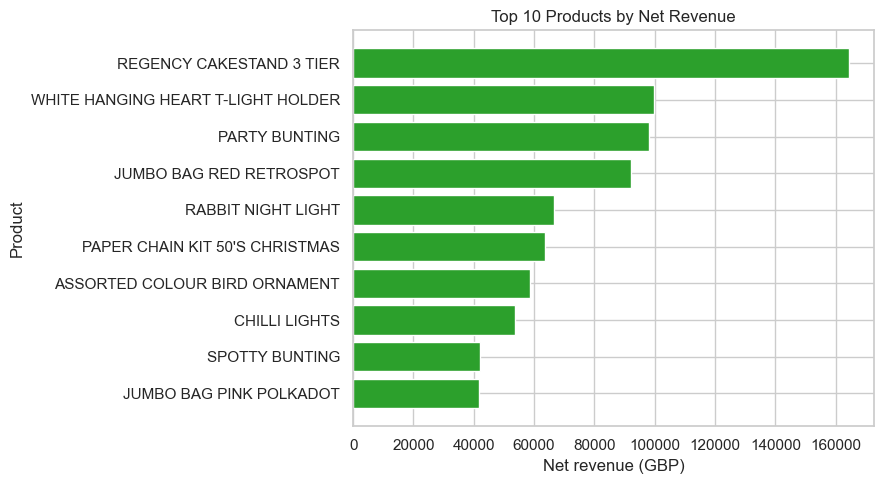

In [19]:
# ---------- FIGURE: top 10 products by NET revenue ----------
top_products = clean_all.groupby("Description")["TotalPrice"].sum().nlargest(10).sort_values()

plt.figure(figsize=(9, 5))
plt.barh(top_products.index, top_products.values, color="#2ca02c")
plt.title("Top 10 Products by Net Revenue")
plt.xlabel("Net revenue (GBP)")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

RESULTS["top_products"] = {name: round(value) for name, value in top_products.iloc[::-1].items()}
RESULTS["top10_share_pct"] = round(top_products.sum() / clean_all["TotalPrice"].sum() * 100, 1)

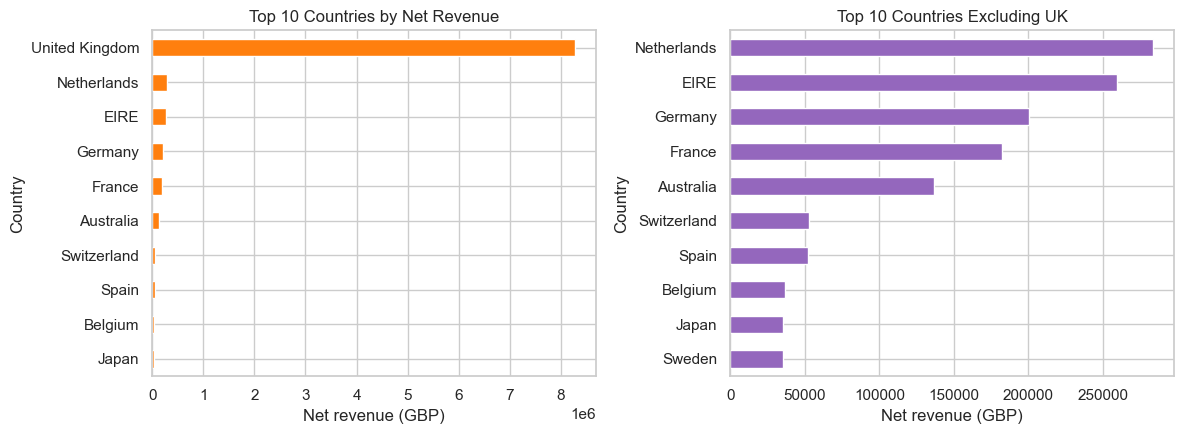

UK share of net revenue: 84.8%


In [20]:
# ---------- FIGURE: country sales (with UK, and without UK so smaller markets are visible) ----------
country_revenue = clean_all.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False)
uk_share = country_revenue["United Kingdom"] / country_revenue.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

country_revenue.head(10).sort_values().plot.barh(ax=axes[0], color="#ff7f0e")
axes[0].set_title("Top 10 Countries by Net Revenue")
axes[0].set_xlabel("Net revenue (GBP)")
axes[0].set_ylabel("Country")

country_revenue.drop("United Kingdom").head(10).sort_values().plot.barh(ax=axes[1], color="#9467bd")
axes[1].set_title("Top 10 Countries Excluding UK")
axes[1].set_xlabel("Net revenue (GBP)")
axes[1].set_ylabel("Country")
plt.tight_layout()
plt.show()

print(f"UK share of net revenue: {uk_share:.1f}%")
RESULTS["uk_revenue_share_pct"] = round(uk_share, 1)
RESULTS["top_countries_ex_uk"] = {name: round(value) for name, value in country_revenue.drop("United Kingdom").head(5).items()}

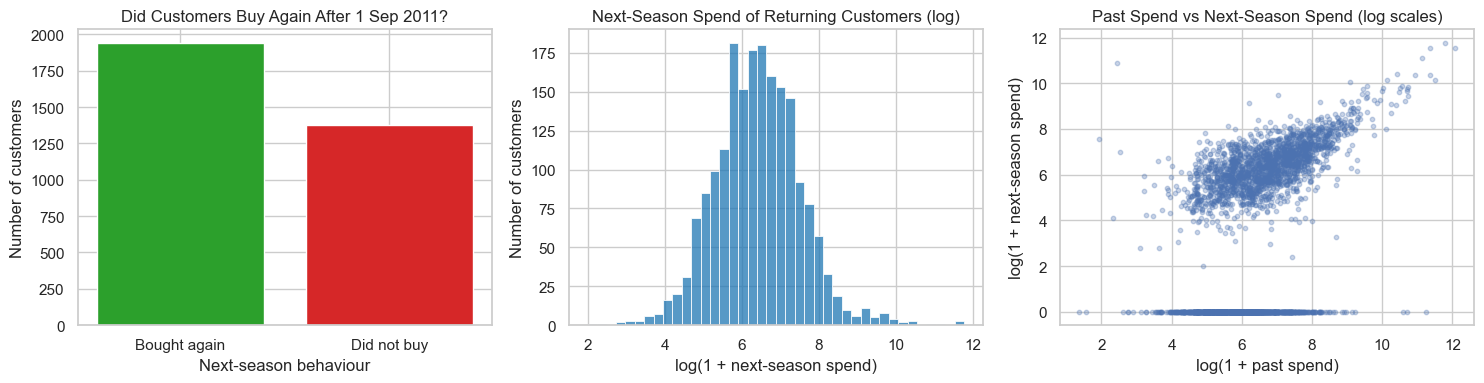

Skewness of next-season spend: raw = 20.93 | after log = -0.13
Share of customers with zero next-season spend: 41.5%


In [21]:
# ---------- FIGURE: the target, next-season spend ----------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (a) how many customers came back?
counts = customers["ActiveNext"].map({0: "Did not buy", 1: "Bought again"}).value_counts()
axes[0].bar(counts.index, counts.values, color=["#2ca02c" if c == "Bought again" else "#d62728" for c in counts.index])
axes[0].set_title("Did Customers Buy Again After 1 Sep 2011?")
axes[0].set_xlabel("Next-season behaviour")
axes[0].set_ylabel("Number of customers")

# (b) how much did the returning customers spend? (log scale because spend is skewed)
active = customers[customers["ActiveNext"] == 1]
sns.histplot(np.log1p(active["FutureSpend"]), bins=40, ax=axes[1], color="#1f77b4")
axes[1].set_title("Next-Season Spend of Returning Customers (log)")
axes[1].set_xlabel("log(1 + next-season spend)")
axes[1].set_ylabel("Number of customers")

# (c) is past spend related to future spend?
axes[2].scatter(np.log1p(customers["GrossSpend"]), np.log1p(customers["FutureSpend"]), alpha=0.3, s=10)
axes[2].set_title("Past Spend vs Next-Season Spend (log scales)")
axes[2].set_xlabel("log(1 + past spend)")
axes[2].set_ylabel("log(1 + next-season spend)")
plt.tight_layout()
plt.show()

skew_raw = stats.skew(customers["FutureSpend"])
skew_log = stats.skew(np.log1p(customers["FutureSpend"]))
print(f"Skewness of next-season spend: raw = {skew_raw:.2f} | after log = {skew_log:.2f}")
print(f"Share of customers with zero next-season spend: {(1 - customers['ActiveNext'].mean()) * 100:.1f}%")
RESULTS["skew_futurespend_raw"] = round(float(skew_raw), 2)
RESULTS["skew_futurespend_log"] = round(float(skew_log), 2)
RESULTS["future_spend_mean"] = round(float(customers["FutureSpend"].mean()), 2)
RESULTS["future_spend_median"] = round(float(customers["FutureSpend"].median()), 2)
RESULTS["future_spend_max"] = round(float(customers["FutureSpend"].max()), 2)
RESULTS["future_spend_mean_active"] = round(float(active["FutureSpend"].mean()), 2)
RESULTS["future_spend_median_active"] = round(float(active["FutureSpend"].median()), 2)

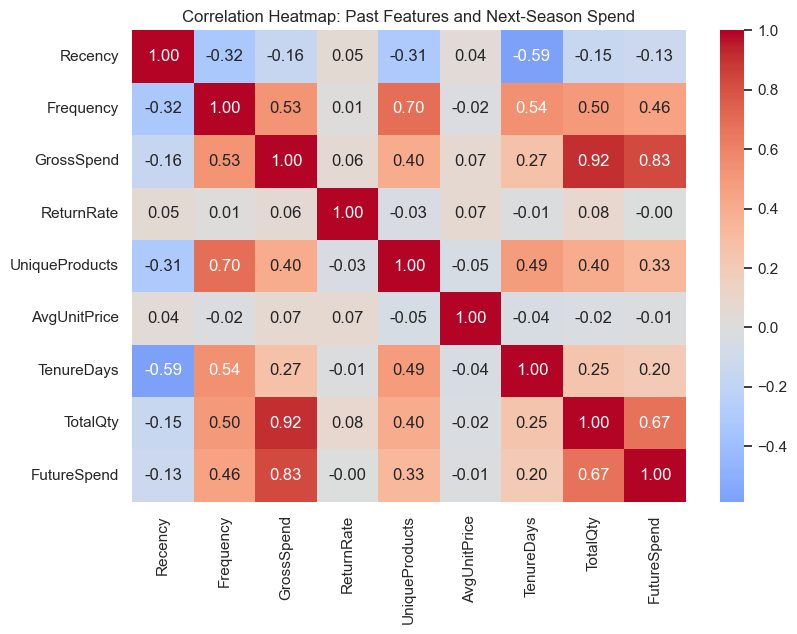

In [22]:
# ---------- FIGURE: correlation heatmap (features and the target) ----------
heatmap_columns = ["Recency", "Frequency", "GrossSpend", "ReturnRate", "UniqueProducts", "AvgUnitPrice", "TenureDays", "TotalQty", "FutureSpend"]
correlation = customers[heatmap_columns].corr()

plt.figure(figsize=(8.5, 6.5))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap: Past Features and Next-Season Spend")
plt.tight_layout()
plt.show()

RESULTS["corr_with_futurespend"] = correlation["FutureSpend"].round(2).to_dict()
RESULTS["corr_frequency_uniqueproducts"] = round(float(correlation.loc["Frequency", "UniqueProducts"]), 2)
RESULTS["corr_grossspend_totalqty"] = round(float(correlation.loc["GrossSpend", "TotalQty"]), 2)

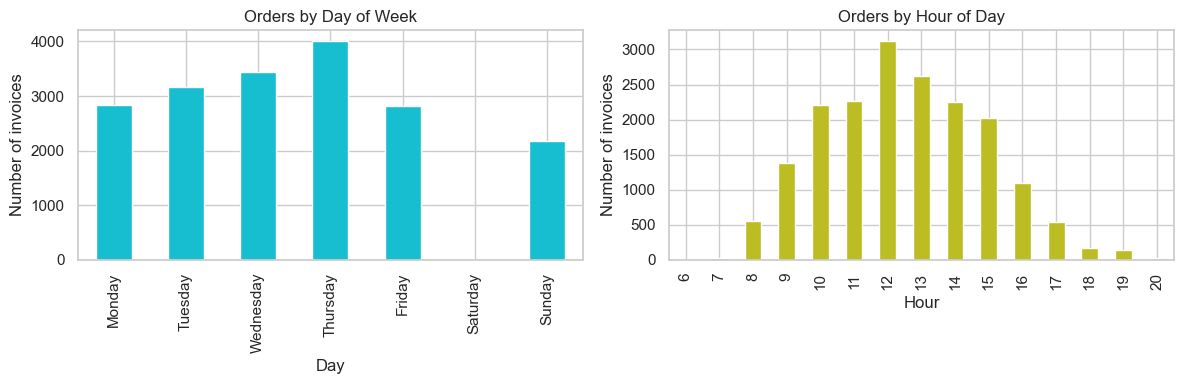

In [23]:
# ---------- FIGURE: when do customers order? (one row per sales invoice) ----------
invoices = df[~df["IsReturn"]].drop_duplicates("InvoiceNo")
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

invoices["InvoiceDay"].value_counts().reindex(weekday_order).plot.bar(ax=axes[0], color="#17becf")
axes[0].set_title("Orders by Day of Week")
axes[0].set_xlabel("Day")
axes[0].set_ylabel("Number of invoices")

invoices["InvoiceHour"].value_counts().sort_index().plot.bar(ax=axes[1], color="#bcbd22")
axes[1].set_title("Orders by Hour of Day")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Number of invoices")
plt.tight_layout()
plt.show()

RESULTS["orders_by_day"] = invoices["InvoiceDay"].value_counts().to_dict()
RESULTS["peak_hour"] = int(invoices["InvoiceHour"].value_counts().idxmax())

In [24]:
# ---------- Descriptive statistics AFTER cleaning (customer level) ----------
customer_descriptives = customers[["Recency", "Frequency", "GrossSpend", "ReturnRate", "FutureSpend"]].apply(describe_full).T
RESULTS["descriptives_customer"] = customer_descriptives.round(3).to_dict("index")
customer_descriptives

,mean,median,mode,min,max,range,variance,std,Q1,Q3,IQR
Recency,92.29,72.50,6.00,0.00,273.00,273.00,"5,889.56",76.74,27.00,146.00,119.00
Frequency,3.42,2.00,1.00,1.00,126.00,125.00,30.71,5.54,1.00,4.00,3.00
GrossSpend,"1,553.22",542.83,76.32,2.90,"175,782.94","175,780.04","35,053,704.66","5,920.62",255.92,"1,340.10","1,084.18"
ReturnRate,0.02,0.00,0.00,0.00,1.00,1.00,0.01,0.08,0.00,0.01,0.01
FutureSpend,824.50,190.32,0.00,0.00,"129,120.07","129,120.07","17,124,914.55","4,138.23",0.00,726.79,726.79


## 4. Task 3: Regression modelling, optimisation and evaluation

**Target y:** `FutureSpend`, what a customer spends after 1 September 2011 (net of returns, a continuous number, 0 if they did not buy).
**Predictors X (all measured before the cutoff):** Recency, Frequency, GrossSpend, ReturnRate, UniqueProducts, AvgUnitPrice, TenureDays, IsUK.

**Why no data leakage:** features come from the past and the target from the future, so the model never sees the answer. `TotalQty` and `AvgBasket` are left out only because they are almost copies of GrossSpend (multicollinearity).

In [25]:
# ---------- 4.1 SELECT FEATURES (X) AND TARGET (y) ----------
feature_names = ["Recency", "Frequency", "GrossSpend", "ReturnRate", "UniqueProducts", "AvgUnitPrice", "TenureDays", "IsUK"]
X = customers[feature_names]      # feature matrix: one row per customer
y = customers["FutureSpend"]      # target vector

print("X shape:", X.shape, "| y shape:", y.shape)
X.head()

X shape: (3314, 8) | y shape: (3314,)


,Recency,Frequency,GrossSpend,ReturnRate,UniqueProducts,AvgUnitPrice,TenureDays,IsUK
CustomerID,,,,,,,,
12346,225,1,"77,183.60",1.00,1,1.04,0,1
12347,29,5,"2,790.86",0.00,82,2.80,237,0
12348,148,3,"1,167.24",0.00,21,0.65,109,0
12350,210,1,294.40,0.00,16,1.58,0,0
12352,162,4,641.51,0.19,24,3.72,34,0


In [26]:
# ---------- 4.2 MODELS AND EVALUATION FUNCTION ----------
# Each model is put in a Pipeline: step 1 scales the features, step 2 fits the model.
# Doing the scaling inside the pipeline means the scaler only learns from the TRAINING data (no leakage).
# The "Baseline" always predicts the average spend. A useful model must beat it.
def make_models():
    return {
        "Baseline (mean)":   Pipeline([("scale", StandardScaler()), ("model", DummyRegressor(strategy="mean"))]),
        "Linear Regression": Pipeline([("scale", StandardScaler()), ("model", LinearRegression())]),
        "Decision Tree":     Pipeline([("scale", StandardScaler()), ("model", DecisionTreeRegressor(max_depth=5, random_state=SEED))]),
        "Random Forest":     Pipeline([("scale", StandardScaler()), ("model", RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1))]),
        "KNN (k=5)":         Pipeline([("scale", StandardScaler()), ("model", KNeighborsRegressor(n_neighbors=5))]),
    }

def run_regression(test_size, use_log_target=False):
    # Splits the data, trains every model, and returns a results table plus the predictions.
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=SEED)

    rows = []
    predictions = {}
    for model_name, model in make_models().items():
        if use_log_target:
            model.fit(X_train, np.log1p(y_train))          # learn on log(1 + spend)
            log_pred = model.predict(X_test)
            # Safety: keep predictions inside the range seen in training, so exp() cannot explode
            log_pred = np.clip(log_pred, 0, np.log1p(y_train).max())
            y_pred = np.expm1(log_pred)                    # convert predictions back to pounds
        else:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

        predictions[model_name] = y_pred
        mse = mean_squared_error(y_test, y_pred)
        rows.append({
            "Split": f"{round((1 - test_size) * 100)}/{round(test_size * 100)}",
            "Target": "log" if use_log_target else "raw",
            "Model": model_name,
            "MAE": mean_absolute_error(y_test, y_pred),    # average absolute error
            "MSE": mse,                                    # average squared error
            "RMSE": np.sqrt(mse),                          # typical error in pounds
            "R2": r2_score(y_test, y_pred),                # share of variation explained (in pounds)
            # Same score on the log scale: less affected by a few very large customers
            # (only for the log-target runs; the raw-target models are not trained for the log scale)
            "R2_log_scale": r2_score(np.log1p(y_test), np.log1p(np.clip(y_pred, 0, None))) if use_log_target else np.nan,
        })
    return pd.DataFrame(rows), predictions, y_test

In [27]:
# ---------- 4.3 RUN THE EXPERIMENTS ----------
results_80_20, preds_80_20, y_test_80_20 = run_regression(test_size=0.20)                      # 80% train / 20% test
results_70_30, preds_70_30, y_test_70_30 = run_regression(test_size=0.30)                      # alternative split
results_80_20_log, preds_80_20_log, _ = run_regression(test_size=0.20, use_log_target=True)   # log target

regression_table = pd.concat([results_80_20, results_70_30, results_80_20_log], ignore_index=True)
RESULTS["regression_table"] = regression_table.round(3).to_dict("records")
regression_table

,Split,Target,Model,MAE,MSE,RMSE,R2,R2_log_scale
0,80/20,raw,Baseline (mean),"1,032.52","18,936,628.46","4,351.62",-0.00,NaN
1,80/20,raw,Linear Regression,769.00,"10,842,833.09","3,292.85",0.43,NaN
2,80/20,raw,Decision Tree,"1,036.41","29,552,717.97","5,436.24",-0.56,NaN
3,80/20,raw,Random Forest,900.18,"17,573,130.65","4,192.03",0.07,NaN
4,80/20,raw,KNN (k=5),721.00,"6,399,350.00","2,529.69",0.66,NaN
5,70/30,raw,Baseline (mean),991.69,"13,838,961.16","3,720.08",-0.00,NaN
6,70/30,raw,Linear Regression,735.48,"8,606,204.73","2,933.63",0.38,NaN
7,70/30,raw,Decision Tree,864.04,"20,167,968.70","4,490.88",-0.46,NaN
8,70/30,raw,Random Forest,751.63,"11,461,383.33","3,385.47",0.17,NaN
9,70/30,raw,KNN (k=5),637.14,"3,976,381.44","1,994.09",0.71,NaN


Best model on the 80/20 split (raw target): KNN (k=5) | R2 = 0.662


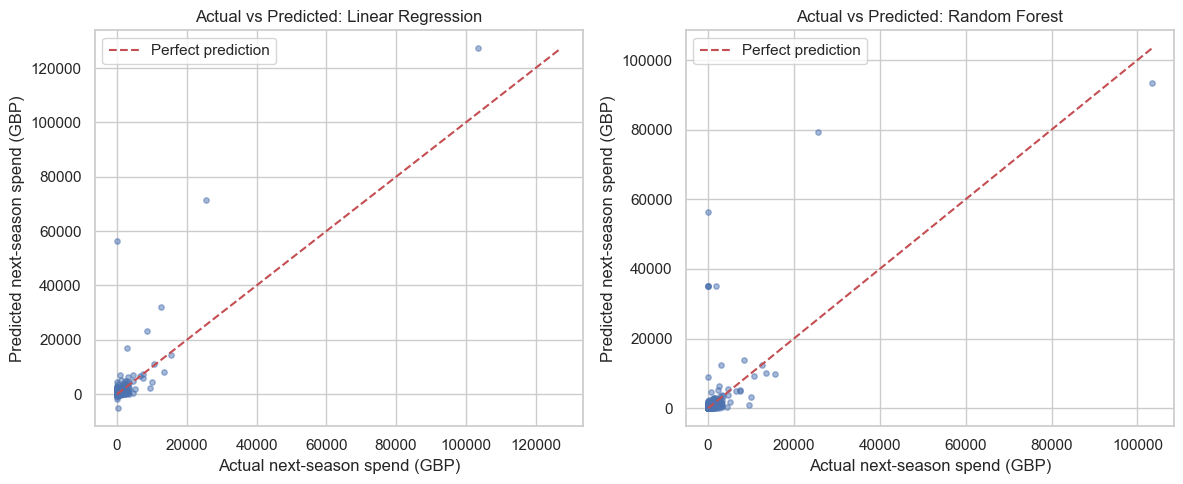

In [28]:
# ---------- 4.4 BEST MODEL AND ACTUAL vs PREDICTED PLOT ----------
real_models = results_80_20[results_80_20["Model"] != "Baseline (mean)"]
best_row = real_models.sort_values("R2", ascending=False).iloc[0]
best_model_name = best_row["Model"]
print("Best model on the 80/20 split (raw target):", best_model_name, "| R2 =", round(best_row["R2"], 3))
RESULTS["best_regression_model_80_20"] = best_model_name

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Left: the simple baseline. Right: the most complex model, for comparison.
for ax, model_name in zip(axes, ["Linear Regression", "Random Forest"]):
    y_pred = preds_80_20[model_name]
    ax.scatter(y_test_80_20, y_pred, alpha=0.5, s=15)
    limit = [0, max(y_test_80_20.max(), y_pred.max())]
    ax.plot(limit, limit, "r--", label="Perfect prediction")    # points on this line = perfect
    ax.set_title(f"Actual vs Predicted: {model_name}")
    ax.set_xlabel("Actual next-season spend (GBP)")
    ax.set_ylabel("Predicted next-season spend (GBP)")
    ax.legend()
plt.tight_layout()
plt.show()

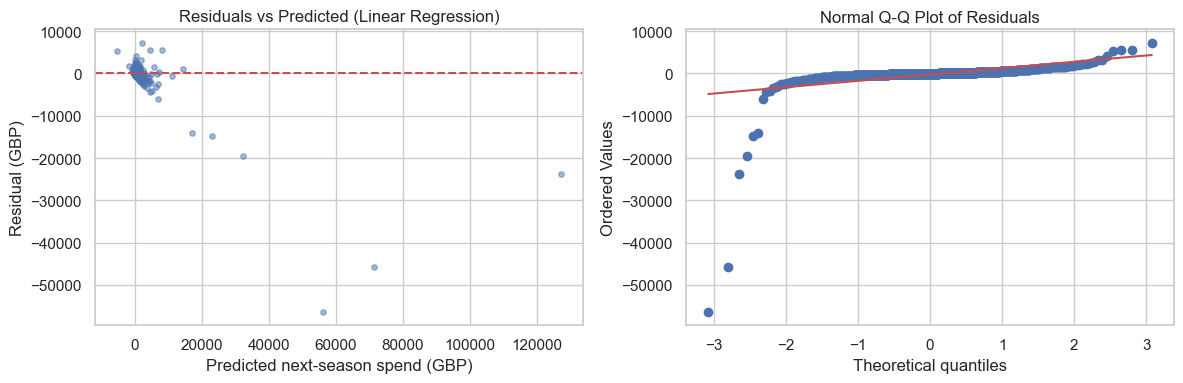

Residual skewness: -12.61


In [29]:
# ---------- 4.5 RESIDUALS (checks the Linear Regression assumptions) ----------
# Residual = actual - predicted. For a good linear model they should look random around 0.
residuals = y_test_80_20 - preds_80_20["Linear Regression"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(preds_80_20["Linear Regression"], residuals, alpha=0.5, s=15)
axes[0].axhline(0, color="r", linestyle="--")
axes[0].set_title("Residuals vs Predicted (Linear Regression)")
axes[0].set_xlabel("Predicted next-season spend (GBP)")
axes[0].set_ylabel("Residual (GBP)")

stats.probplot(residuals, plot=axes[1])       # Q-Q plot: points on the line = normal residuals
axes[1].set_title("Normal Q-Q Plot of Residuals")
plt.tight_layout()
plt.show()

print("Residual skewness:", round(float(stats.skew(residuals)), 2))
RESULTS["lr_residual_skew"] = round(float(stats.skew(residuals)), 2)

In [30]:
# ---------- 4.6 CROSS-VALIDATION (5 splits: a more reliable score than one split) ----------
cv_rows = []
for model_name, model in make_models().items():
    if model_name == "Baseline (mean)":
        continue
    scores = cross_val_score(model, X, y, cv=5, scoring="r2")                       # raw pounds
    scores_log = cross_val_score(model, X, np.log1p(y), cv=5, scoring="r2")         # log scale
    cv_rows.append({"Model": model_name, "CV R2 mean": scores.mean(), "CV R2 std": scores.std(),
                    "CV R2 log-scale mean": scores_log.mean(), "CV R2 log-scale std": scores_log.std()})

cv_table = pd.DataFrame(cv_rows)
RESULTS["cv_r2"] = cv_table.round(3).to_dict("records")
cv_table

,Model,CV R2 mean,CV R2 std,CV R2 log-scale mean,CV R2 log-scale std
0,Linear Regression,0.23,0.78,0.22,0.03
1,Decision Tree,-1.29,2.12,0.24,0.03
2,Random Forest,-0.11,1.13,0.23,0.03
3,KNN (k=5),0.42,0.21,0.12,0.03


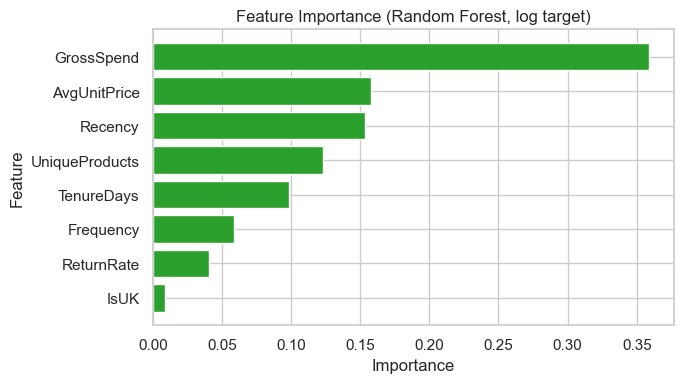

In [31]:
# ---------- 4.7 WHAT DRIVES NEXT-SEASON SPEND? (Random Forest feature importance) ----------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=SEED)
forest = RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1).fit(X_train, np.log1p(y_train))
importance = pd.Series(forest.feature_importances_, index=feature_names).sort_values()

plt.figure(figsize=(7, 4))
plt.barh(importance.index, importance.values, color="#2ca02c")
plt.title("Feature Importance (Random Forest, log target)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

RESULTS["feature_importance"] = importance.sort_values(ascending=False).round(3).to_dict()

### Optimisation idea behind regression (loss minimisation)
Regression chooses the parameters $\beta$ that minimise the **mean squared error loss**:

$$L(\beta) = \frac{1}{n}\sum_{i=1}^{n}\left(y_i - x_i^{\top}\beta\right)^2$$

The **derivative** (gradient) tells us the slope of the loss. Moving $\beta$ opposite to the slope lowers the error. This is **gradient descent**, with learning rate $\alpha$:

$$\frac{\partial L}{\partial \beta} = -\frac{2}{n}X^{\top}(y - X\beta), \qquad \beta \leftarrow \beta - \alpha\frac{\partial L}{\partial \beta}$$

The closed-form answer (normal equation) is $\hat\beta = (X^{\top}X)^{-1}X^{\top}y$. Below we check that gradient descent, the normal equation and scikit-learn agree.

Gradient descent : slope = 0.8271, intercept = -0.0000
Normal equation  : slope = 0.8271, intercept = -0.0000
scikit-learn     : slope = 0.8271, intercept = -0.0000


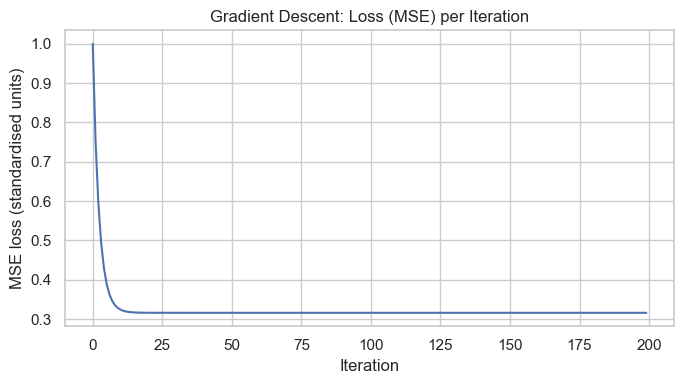

In [32]:
# ---------- 4.8 GRADIENT DESCENT FROM SCRATCH (one feature, standardised) ----------
x_std = StandardScaler().fit_transform(customers[["GrossSpend"]]).ravel()    # feature: past spend
y_std = StandardScaler().fit_transform(customers[["FutureSpend"]]).ravel()   # target: next-season spend
n = len(x_std)

w = 0.0               # slope, start at 0
b = 0.0               # intercept, start at 0
learning_rate = 0.1
loss_history = []

for step in range(200):
    y_hat = w * x_std + b                              # current predictions
    loss_history.append(np.mean((y_std - y_hat) ** 2)) # current MSE loss
    dw = -2 / n * np.sum(x_std * (y_std - y_hat))      # derivative of loss with respect to w
    db = -2 / n * np.sum(y_std - y_hat)                # derivative of loss with respect to b
    w = w - learning_rate * dw                         # move against the slope
    b = b - learning_rate * db

# Normal equation:  beta = (X^T X)^(-1) X^T y   (X has a column of ones for the intercept)
X_design = np.column_stack([np.ones(n), x_std])
beta_normal = np.linalg.inv(X_design.T @ X_design) @ X_design.T @ y_std

# scikit-learn for comparison
sk_model = LinearRegression().fit(x_std.reshape(-1, 1), y_std)

print(f"Gradient descent : slope = {w:.4f}, intercept = {b:.4f}")
print(f"Normal equation  : slope = {beta_normal[1]:.4f}, intercept = {beta_normal[0]:.4f}")
print(f"scikit-learn     : slope = {sk_model.coef_[0]:.4f}, intercept = {sk_model.intercept_:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(loss_history)
plt.title("Gradient Descent: Loss (MSE) per Iteration")
plt.xlabel("Iteration")
plt.ylabel("MSE loss (standardised units)")
plt.tight_layout()
plt.show()

RESULTS["gradient_descent"] = {"slope": round(float(w), 4), "normal_eq_slope": round(float(beta_normal[1]), 4),
                               "sklearn_slope": round(float(sk_model.coef_[0]), 4), "final_loss": round(float(loss_history[-1]), 4)}

## 5. Task 4A: Classification for decision support

**Target: next-season status** (a clear rule, using the customer's spend after 1 September 2011):
- **Inactive:** spent nothing (did not come back)
- **Low-value:** came back and spent at or below the median of returning customers
- **High-value:** came back and spent above that median

**Why useful:** each class has a different action: win-back offers for likely Inactive customers, nurturing for Low-value, VIP protection for High-value. The class is **ordinal**: Inactive < Low-value < High-value.
The same past features as in regression are used (no leakage).

In [33]:
# ---------- 5.1 CREATE THE CLASS LABEL ----------
active_median = customers.loc[customers["ActiveNext"] == 1, "FutureSpend"].median()    # median spend of returning customers
print(f"Median next-season spend of returning customers: {active_median:.2f}")

# np.select applies the first rule that is true for each customer
customers["NextStatus"] = np.select(
    [customers["FutureSpend"] == 0, customers["FutureSpend"] <= active_median],
    ["Inactive", "Low-value"],
    default="High-value",
)

class_counts = customers["NextStatus"].value_counts().reindex(["Inactive", "Low-value", "High-value"])
print(class_counts)
RESULTS["active_median_futurespend"] = round(float(active_median), 2)
RESULTS["next_status_counts"] = class_counts.to_dict()

# Split into train and test. stratify keeps the same class mix in both parts.
y_class = customers["NextStatus"]
X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.20, random_state=SEED, stratify=y_class)
print("\nTrain:", X_train.shape, "| Test:", X_test.shape)

Median next-season spend of returning customers: 596.86
NextStatus
Inactive      1376
Low-value      969
High-value     969
Name: count, dtype: int64

Train: (2651, 8) | Test: (663, 8)


In [34]:
# ---------- 5.2 TRAIN AND EVALUATE TWO CLASSIFIERS ----------
classifiers = {
    "Logistic Regression": Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000, random_state=SEED))]),
    "Decision Tree":       Pipeline([("scale", StandardScaler()), ("model", DecisionTreeClassifier(max_depth=4, random_state=SEED))]),
}

classification_rows = []
class_predictions = {}
for model_name, model in classifiers.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    class_predictions[model_name] = y_pred
    classification_rows.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),                              # share of correct predictions
        "Precision (macro)": precision_score(y_test, y_pred, average="macro"),   # of predicted X, how many really are X
        "Recall (macro)": recall_score(y_test, y_pred, average="macro"),         # of real X, how many did we find
        "F1 (macro)": f1_score(y_test, y_pred, average="macro"),                 # balance of precision and recall
    })

# Simple baseline for comparison: always predict the most common class
majority_class = y_train.value_counts().idxmax()
baseline_accuracy = (y_test == majority_class).mean()
print(f"Baseline (always '{majority_class}') accuracy = {baseline_accuracy:.3f}")
RESULTS["classification_baseline_accuracy"] = round(float(baseline_accuracy), 3)
RESULTS["classification_baseline_class"] = majority_class

classification_table = pd.DataFrame(classification_rows)
RESULTS["classification_table"] = classification_table.round(3).to_dict("records")
classification_table

Baseline (always 'Inactive') accuracy = 0.415


,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro)
0,Logistic Regression,0.58,0.57,0.55,0.54
1,Decision Tree,0.56,0.53,0.53,0.51


              precision    recall  f1-score   support

    Inactive       0.56      0.79      0.66       275
   Low-value       0.50      0.27      0.35       194
  High-value       0.65      0.59      0.62       194

    accuracy                           0.58       663
   macro avg       0.57      0.55      0.54       663
weighted avg       0.57      0.58      0.55       663



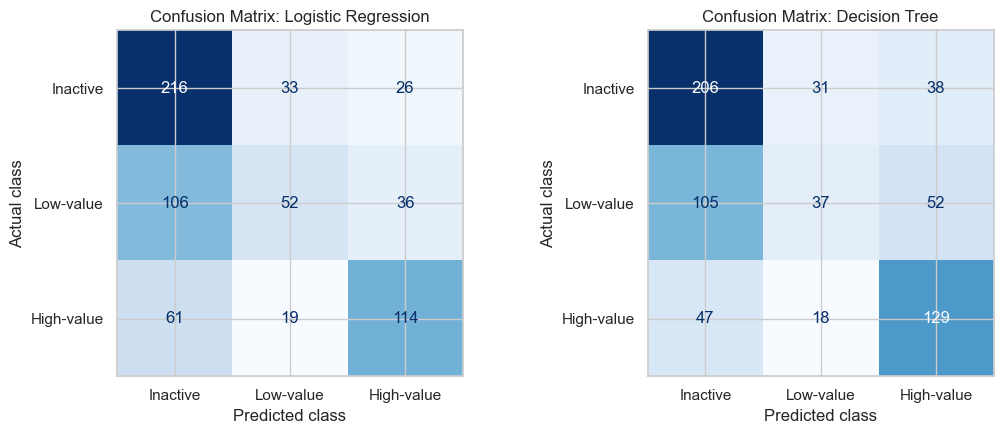

In [35]:
# ---------- 5.3 DETAILED REPORT AND CONFUSION MATRIX ----------
class_labels = ["Inactive", "Low-value", "High-value"]
print(classification_report(y_test, class_predictions["Logistic Regression"], labels=class_labels))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, model_name in zip(axes, classifiers):
    matrix = confusion_matrix(y_test, class_predictions[model_name], labels=class_labels)
    ConfusionMatrixDisplay(matrix, display_labels=class_labels).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"Confusion Matrix: {model_name}")
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("Actual class")
plt.tight_layout()
plt.show()

RESULTS["confusion_matrix_logreg"] = confusion_matrix(y_test, class_predictions["Logistic Regression"], labels=class_labels).tolist()
RESULTS["confusion_matrix_tree"] = confusion_matrix(y_test, class_predictions["Decision Tree"], labels=class_labels).tolist()
RESULTS["classification_test_size"] = len(y_test)

### Role of the sigmoid function in Logistic Regression
Logistic regression turns a linear score $z = x^{\top}\beta$ into a probability between 0 and 1 with the **logistic sigmoid**, a transcendental function that uses $e$:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

A large positive $z$ gives a probability near 1, a large negative $z$ gives near 0. For three classes the model uses the softmax version. It is trained by minimising log-loss with derivatives.

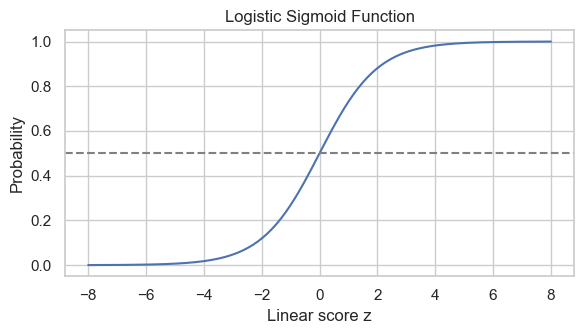

In [36]:
# ---------- FIGURE: the sigmoid curve ----------
z = np.linspace(-8, 8, 200)
plt.figure(figsize=(6, 3.5))
plt.plot(z, 1 / (1 + np.exp(-z)))
plt.axhline(0.5, color="grey", linestyle="--")
plt.title("Logistic Sigmoid Function")
plt.xlabel("Linear score z")
plt.ylabel("Probability")
plt.tight_layout()
plt.show()

## 6. Task 4B: Clustering (returns-aware customer segmentation)
We cluster customers on **Recency, Frequency, Monetary (gross spend) and ReturnRate**. The first three are skewed, so we use `log1p`; then all four are standardised because K-means uses distances.
**Extra step (our idea):** after clustering, we check whether the segments really behave differently in the *next* season.

In [37]:
# ---------- 6.1 WHAT HAPPENS WITHOUT SCALING? (k = 4 as a demo) ----------
# cluster_scaled (log + standardised) was created in Section 2.10
km_unscaled = KMeans(n_clusters=4, random_state=SEED, n_init=10).fit(raw_features)       # raw values
km_scaled = KMeans(n_clusters=4, random_state=SEED, n_init=10).fit(cluster_scaled)       # scaled values

sil_unscaled = silhouette_score(raw_features, km_unscaled.labels_)
sil_scaled = silhouette_score(cluster_scaled, km_scaled.labels_)

print(f"Silhouette WITHOUT scaling: {sil_unscaled:.3f} | WITH log + scaling: {sil_scaled:.3f}")
print("Cluster sizes without scaling:", np.bincount(km_unscaled.labels_).tolist())
print("Cluster sizes with scaling   :", np.bincount(km_scaled.labels_).tolist())

RESULTS["scaling_effect_k4"] = {"silhouette_raw": round(float(sil_unscaled), 3), "silhouette_scaled": round(float(sil_scaled), 3),
                                "sizes_raw": np.bincount(km_unscaled.labels_).tolist(),
                                "sizes_scaled": np.bincount(km_scaled.labels_).tolist()}

Silhouette WITHOUT scaling: 0.954 | WITH log + scaling: 0.333
Cluster sizes without scaling: [3286, 2, 21, 5]
Cluster sizes with scaling   : [534, 1244, 1479, 57]


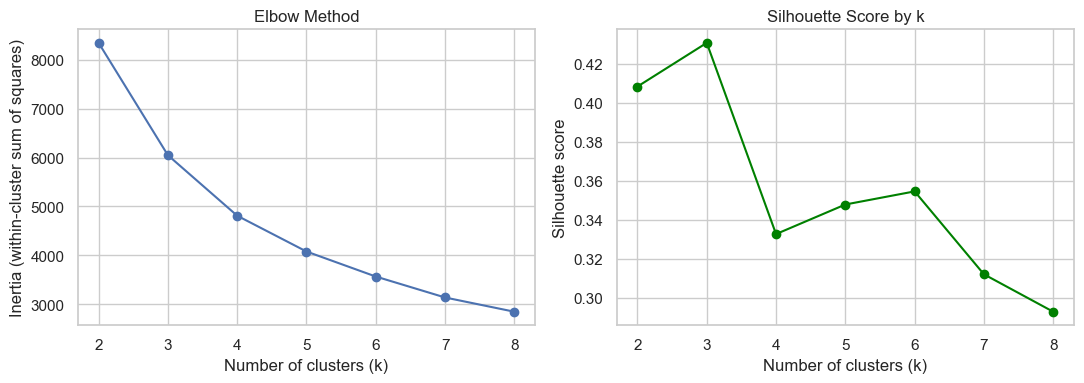

,k,inertia,silhouette
0,2,"8,348.48",0.41
1,3,"6,047.21",0.43
2,4,"4,808.41",0.33
3,5,"4,075.21",0.35
4,6,"3,563.06",0.35
5,7,"3,133.87",0.31
6,8,"2,842.35",0.29


In [38]:
# ---------- 6.2 CHOOSING k: elbow method and silhouette score ----------
k_values = range(2, 9)
inertias = []       # inertia = total squared distance to cluster centres (lower = tighter clusters)
silhouettes = []    # silhouette = how well separated the clusters are (higher = better, max 1)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(cluster_scaled)
    inertias.append(model.inertia_)
    silhouettes.append(silhouette_score(cluster_scaled, model.labels_))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(list(k_values), inertias, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia (within-cluster sum of squares)")
axes[1].plot(list(k_values), silhouettes, marker="o", color="green")
axes[1].set_title("Silhouette Score by k")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score")
plt.tight_layout()
plt.show()

selection_table = pd.DataFrame({"k": list(k_values), "inertia": inertias, "silhouette": silhouettes})
RESULTS["cluster_selection"] = selection_table.round(3).to_dict("records")
selection_table

In [39]:
# ---------- 6.3 FIT THE FINAL K-MEANS MODEL ----------
# Rule: pick the best silhouette among k = 3, 4, 5 (a manager can act on 3 to 5 groups; k = 2 is too coarse).
allowed = {k: s for k, s in zip(k_values, silhouettes) if 3 <= k <= 5}
K = max(allowed, key=allowed.get)
# >>> You may override this after looking at the elbow plot, e.g. K = 4 <<<
print("Chosen k =", K, "| silhouette =", round(allowed[K], 3))

kmeans = KMeans(n_clusters=K, random_state=SEED, n_init=10).fit(cluster_scaled)
customers["Cluster"] = kmeans.labels_

RESULTS["chosen_k"] = int(K)
RESULTS["chosen_k_silhouette"] = round(float(allowed[K]), 3)

# Profile: average behaviour of each cluster (in real units, not scaled),
# PLUS what the cluster did in the NEXT season (this is our extra validation step).
profile = customers.groupby("Cluster").agg(
    Customers=("Recency", "size"),
    Recency=("Recency", "mean"),
    Frequency=("Frequency", "mean"),
    Monetary=("GrossSpend", "mean"),
    ReturnRate=("ReturnRate", "mean"),
    FutureSpend=("FutureSpend", "mean"),
    ActiveNext=("ActiveNext", "mean"),
    FutureTotal=("FutureSpend", "sum"),
)
profile["Customer share %"] = profile["Customers"] / profile["Customers"].sum() * 100
profile["Next-season revenue share %"] = profile["FutureTotal"] / profile["FutureTotal"].sum() * 100
profile["Bought again %"] = profile["ActiveNext"] * 100
profile

Chosen k = 3 | silhouette = 0.431


,Customers,Recency,Frequency,Monetary,ReturnRate,FutureSpend,ActiveNext,FutureTotal,Customer share %,Next-season revenue share %,Bought again %
Cluster,,,,,,,,,,,
0,2122,124.59,1.51,435.35,0.01,286.01,0.46,"606,905.09",64.03,22.21,45.85
1,57,123.68,2.37,"2,908.14",0.54,350.09,0.47,"19,955.27",1.72,0.73,47.37
2,1135,30.31,7.05,"3,575.16",0.02,"1,855.09",0.83,"2,105,529.45",34.25,77.06,82.64


In [40]:
# ---------- 6.4 GIVE EACH CLUSTER A BUSINESS NAME (rule-based suggestion, EDIT after reading the table) ----------
names = {}
remaining = list(profile.index)

# Rule 1: the cluster with the highest average spend = High-value loyal
top_cluster = profile["Monetary"].idxmax()
names[top_cluster] = "High-value loyal customers"
remaining.remove(top_cluster)

# Rule 2: a cluster whose return rate is at least 1.5 times the overall average = High-return buyers
overall_return_rate = customers["ReturnRate"].mean()
if remaining:
    most_returns = profile.loc[remaining, "ReturnRate"].idxmax()
    if profile.loc[most_returns, "ReturnRate"] >= 1.5 * overall_return_rate:
        names[most_returns] = "High-return buyers"
        remaining.remove(most_returns)

# Rule 3: the cluster that has been away longest = Lapsed / low-value
if remaining:
    lapsed = profile.loc[remaining, "Recency"].idxmax()
    names[lapsed] = "Lapsed / low-value customers"
    remaining.remove(lapsed)

# Rule 4: whatever is left, ordered by spend
leftover_names = ["Regular customers", "Recent small buyers", "Other customers"]
for i, cluster in enumerate(sorted(remaining, key=lambda c: -profile.loc[c, "Monetary"])):
    names[cluster] = leftover_names[i]

customers["Segment"] = customers["Cluster"].map(names)
profile["Segment"] = profile.index.map(names)
RESULTS["overall_return_rate"] = round(float(overall_return_rate), 3)
RESULTS["cluster_profile"] = profile.round(3).reset_index().to_dict("records")
profile[["Segment", "Customers", "Customer share %", "Recency", "Frequency", "Monetary", "ReturnRate",
         "Bought again %", "FutureSpend", "Next-season revenue share %"]].sort_values("Monetary", ascending=False)

,Segment,Customers,Customer share %,Recency,Frequency,Monetary,ReturnRate,Bought again %,FutureSpend,Next-season revenue share %
Cluster,,,,,,,,,,
2,High-value loyal customers,1135,34.25,30.31,7.05,"3,575.16",0.02,82.64,"1,855.09",77.06
1,High-return buyers,57,1.72,123.68,2.37,"2,908.14",0.54,47.37,350.09,0.73
0,Lapsed / low-value customers,2122,64.03,124.59,1.51,435.35,0.01,45.85,286.01,22.21


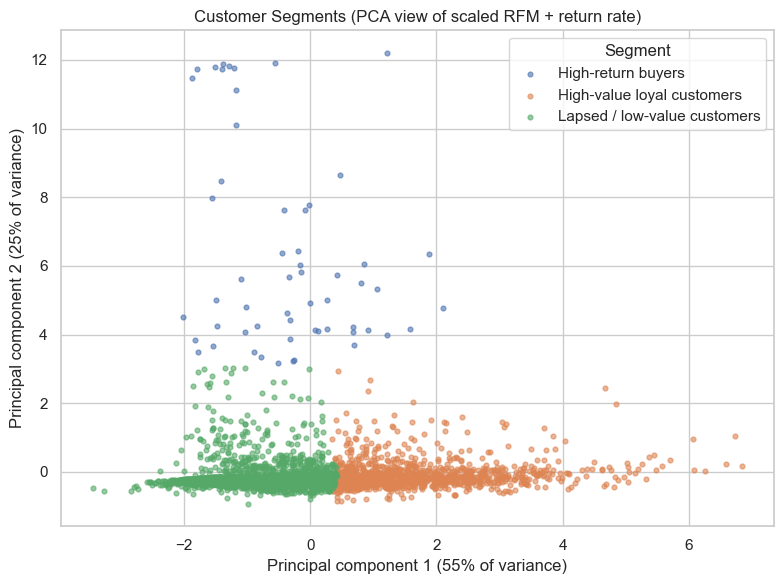

In [41]:
# ---------- FIGURE: clusters in 2D using PCA ----------
# PCA squeezes 4 features into 2 so we can draw the clusters on a flat chart.
pca = PCA(n_components=2, random_state=SEED)
points = pca.fit_transform(cluster_scaled)

plt.figure(figsize=(8, 6))
for segment in customers["Segment"].unique():
    mask = (customers["Segment"] == segment).values
    plt.scatter(points[mask, 0], points[mask, 1], s=12, alpha=0.6, label=segment)
plt.title("Customer Segments (PCA view of scaled RFM + return rate)")
plt.xlabel(f"Principal component 1 ({pca.explained_variance_ratio_[0] * 100:.0f}% of variance)")
plt.ylabel(f"Principal component 2 ({pca.explained_variance_ratio_[1] * 100:.0f}% of variance)")
plt.legend(title="Segment")
plt.tight_layout()
plt.show()

RESULTS["pca_explained_variance"] = [round(float(v), 3) for v in pca.explained_variance_ratio_]

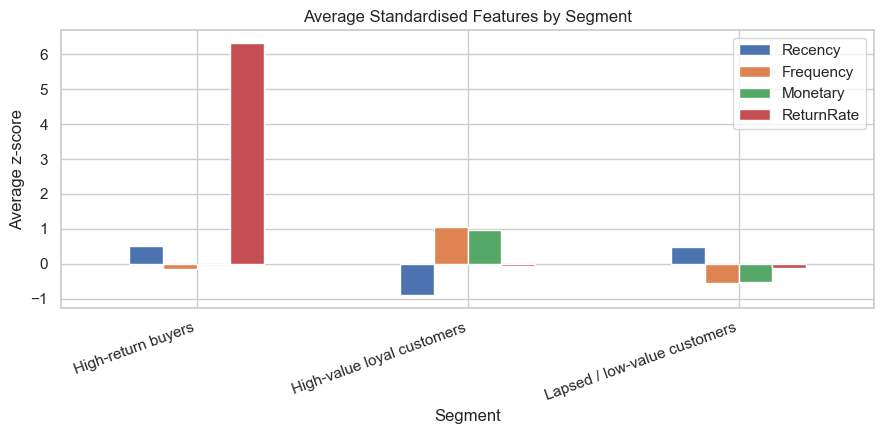

In [42]:
# ---------- FIGURE: segment behaviour (standardised) ----------
segment_profile = pd.DataFrame(cluster_scaled, columns=["Recency", "Frequency", "Monetary", "ReturnRate"], index=customers.index)
segment_profile["Segment"] = customers["Segment"]

segment_profile.groupby("Segment").mean().plot.bar(figsize=(9, 4.5))
plt.title("Average Standardised Features by Segment")
plt.xlabel("Segment")
plt.ylabel("Average z-score")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

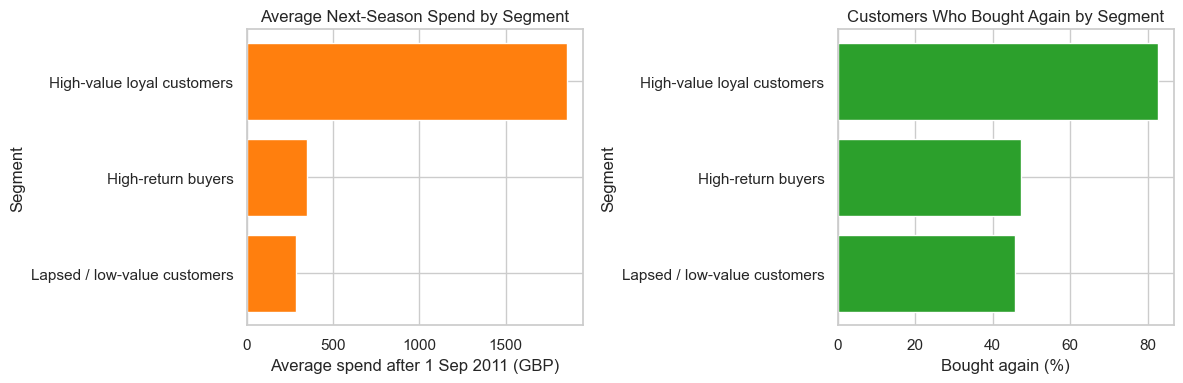

In [43]:
# ---------- FIGURE: do the segments behave differently NEXT season? (our validation step) ----------
by_segment = customers.groupby("Segment").agg(FutureSpend=("FutureSpend", "mean"), BoughtAgain=("ActiveNext", "mean"))
by_segment = by_segment.sort_values("FutureSpend")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].barh(by_segment.index, by_segment["FutureSpend"], color="#ff7f0e")
axes[0].set_title("Average Next-Season Spend by Segment")
axes[0].set_xlabel("Average spend after 1 Sep 2011 (GBP)")
axes[0].set_ylabel("Segment")
axes[1].barh(by_segment.index, by_segment["BoughtAgain"] * 100, color="#2ca02c")
axes[1].set_title("Customers Who Bought Again by Segment")
axes[1].set_xlabel("Bought again (%)")
axes[1].set_ylabel("Segment")
plt.tight_layout()
plt.show()

## 7. Task 5 and 6: Insights, limitations and reproducibility

**Complete these in your report, in your own words, using the outputs above:**
- **Most useful insights:** which segment brings most next-season revenue, how big returns are, which features predict next-season spend.
- **Results to treat with caution:** regression R-squared (many zero-spend customers and a few very large ones), segments depend on the chosen k, the UK dominates sales.
- **Limitations:** missing CustomerID, only one season to predict, new customers cannot be predicted, one random split, class cut-offs, ethical risks of unfair treatment.
- **Improvements:** cross-validation and tuning, more algorithms (for example gradient boosting), rolling time windows, more variables, external business data.

**Reproducibility:** random seed 42, all steps are in code, libraries are in `requirements.txt`.

In [44]:
# ---------- SAVE THE RESULTS SUMMARY (numbers for the report) ----------
RESULTS["cleaning_log"] = cleaning_log
RESULTS["raw_descriptives"] = raw_descriptives.round(2).to_dict("index")
RESULTS["raw_checks"] = quality_checks
RESULTS["cutoff_date"] = str(CUTOFF.date())

def to_plain(obj):
    # Converts numpy numbers into normal Python numbers so they can be saved as JSON.
    if isinstance(obj, dict):
        return {str(k): to_plain(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [to_plain(v) for v in obj]
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    return obj

with open("results_summary.json", "w") as file:
    json.dump(to_plain(RESULTS), file, indent=2)
print("Saved results_summary.json")

Saved results_summary.json


In [45]:
# ---------- LIBRARY VERSIONS (for the report references and reproducibility) ----------
import sklearn, scipy, matplotlib
print("pandas", pd.__version__, "| numpy", np.__version__, "| scikit-learn", sklearn.__version__,
      "| scipy", scipy.__version__, "| matplotlib", matplotlib.__version__, "| seaborn", sns.__version__)

pandas 2.3.3 | numpy 2.3.5 | scikit-learn 1.7.2 | scipy 1.16.3 | matplotlib 3.10.6 | seaborn 0.13.2
